# Step 2a — Kneedle filter

Turn the raw walk trajectories from `02_semantic_walk.ipynb` into training sentences using a **per-anchor adaptive threshold**, the third of three threshold methods (alongside `02a_filter_constant_theta.ipynb` and `02a_filter_pct_dropoff.ipynb`). For each anchor we rank the whole catalogue by Step 1 similarity and locate the **knee** of that ranked curve — the point where it bends from steep decline into a long flat tail — with the Kneedle algorithm (Satopää et al. 2011, via the `kneed` package). The similarity at the knee becomes that anchor's own `theta`. Then, exactly like the two sibling filters, we rebuild `sentence = [anchor] + [every raw_path[i+1] whose raw_sims[i] >= theta_anchor]` and keep sentences with at least `min_sentence_length` products.

Where `pct_dropoff` asks "is there one sharp single-step drop somewhere in the top ranks", Kneedle asks about the **whole shape**: where does steep decline turn into flat tail. That distinction matters here directly — pct_dropoff found that 91.5% of anchors never produced a qualifying single-step 10% drop within their top 50 ranks, i.e. most of these curves are gradual, not cliff-shaped. Kneedle is built for exactly that gradual case, so this run tests whether it recovers a meaningful boundary where the simpler rule mostly could not.

The threshold decides only what gets **logged**, never where the walk went — every filter notebook reads the same `walk_raw_paths.jsonl`, so all three methods are compared on identical trajectories.

**Inputs** (in `outputs/`)
- `walk_raw_paths.jsonl` — raw walks (`anchor_id`, `raw_path`, `raw_sims`, `hops_taken`)
- `walk_config.json` — the walk run this filter is built on (for traceability)
- `product_basket_freq.json` — per-product basket counts for the popularity check
- `embeddings.npy` + `product_id_to_index.json` — Step 1 vectors, used **here to compute the adaptive thresholds themselves** (not only for the rank-novelty diagnostic); `products_text.csv` for product names

**Outputs** (to `outputs/`)
- `filters/kneedle/sensitivity_1.0/thresholds.json` — per-anchor `{theta, knee_rank, n_candidates_kept, fallback}`
- `filters/kneedle/sensitivity_1.0/walk_sentences.jsonl` — one kept sentence per line
- `filters/kneedle/sensitivity_1.0/filter_config.json` — method, knee_sensitivity, min length, timestamps
- `filters/kneedle/sensitivity_1.0/walk_sentences_readable.txt` — human-readable kept sentences

**Requires** `kneed` installed in the local venv (`from kneed import KneeLocator`); install it by hand before running this notebook.

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import time
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters

Kneedle has one main knob, its sensitivity `S`, kept here as a named constant (same reasoning as `DROP_PCT` / `SEARCH_WINDOW` in pct_dropoff) so it is easy to sweep later. There is no single `theta` — each anchor gets its own, computed in §4 — except when no knee is found, where the method falls back to the constant baseline.

In [2]:
METHOD_NAME = "kneedle"
VALUE_LABEL = "sensitivity_1.0"
FILTER_DIR = OUT_DIR / "filters" / METHOD_NAME / VALUE_LABEL
FILTER_DIR.mkdir(parents=True, exist_ok=True)

# ---- Adaptive threshold rule ----
KNEE_SENSITIVITY = 1.0   # kneed's own "S" parameter — the paper's suggested default.
                         # Higher = more conservative (demands more sustained flatness
                         # before calling a knee); lower = more readily detects one.
                         # Kept as a named, sweepable constant, same reasoning as
                         # DROP_PCT / SEARCH_WINDOW in pct_dropoff.

CONSTANT_THETA_BASELINE = 0.70   # the fixed baseline this method is compared against;
                                 # ALSO doubles as the fallback theta when no knee is
                                 # found for an anchor (see §4).

min_sentence_length = 2    # discard sentences shorter than this (same rule as siblings)

# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Everything this notebook needs was produced upstream: the raw walks and walk config from `02_semantic_walk.ipynb`, the per-product basket counts (so the popularity check never rebuilds the basket graph), and Step 1's embeddings + id map — used **both** to compute the per-anchor thresholds (§4) and for the rank novelty test.

In [3]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Rank each anchor and compute its per-anchor theta via Kneedle

We reuse `anchor_sorted_sims` from pct_dropoff **exactly as-is**: cosine the anchor against the whole catalogue, mask its own index to `-inf` *before* sorting (self-similarity 1.0 would be a fake rank-1 boundary), and sort descending, never truncated. Kneedle needs the true full tail to tell a real knee from noise, so keeping the ranking full matters even more here than it did for pct_dropoff's bounded window search.

**Why `curve="convex", direction="decreasing"` (hardcoded).** Our similarity-vs-rank curve starts high and falls fast, then flattens into a long tail — the same shape as the package's own canonical k-means elbow example (inertia vs `k`). We fix this choice for every anchor rather than auto-detecting it per anchor with kneed's `find_shape()`: per-anchor auto-detection risks picking inconsistent curve/direction between anchors, which would undermine the cross-anchor comparability this whole method comparison depends on. One fixed, justified choice, applied uniformly.

**Reading `theta` at the knee.** `KneeLocator` returns the knee's x-location (a rank). We read the *observed* similarity at that rank straight from the sorted array, not `kl.knee_y`, so `theta` is always a real data value regardless of any interpolation kneed did internally. When no knee is found we fall back to `CONSTANT_THETA_BASELINE`.

**One guard on the input.** `anchor_sorted_sims` leaves the masked `-inf` self value as the last element of the descending array. pct_dropoff never reaches it (it only reads the top ranks), but Kneedle consumes the whole curve, and a `-inf` collapses kneed's internal [0,1] normalisation. We drop that single sentinel before the call, leaving exactly the ~49,687 real catalogue points the method reasons about (see the "~49,687" figure below); the ranking itself is still never truncated.

Before running across all walked anchors we do two pre-flight checks, since kneed's per-call cost at ~49,687 points is a real unknown (unlike pct_dropoff's near-instant bounded search): a behavioural check on the six stress-test anchors, and a timing estimate on 200 random anchors.

In [4]:
def anchor_sorted_sims(anchor_id):
    """Full descending similarity of the whole catalogue to this anchor.

    Mask the anchor's own row to -inf BEFORE sorting: its self-similarity is 1.0
    and, left in, would look like a guaranteed rank-1 cliff for every anchor. The
    ranking is kept FULL (never truncated) — only the drop search bounds depth.
    """
    a = pid_to_idx[anchor_id]
    sims = embeddings @ embeddings[a]      # cosine vs anchor (unit-norm); fresh array
    sims[a] = -np.inf                      # mask self before sorting, not after
    return np.sort(sims)[::-1]             # descending; sorted_sims[0] = rank 1


def kneedle_theta(sorted_sims):
    """Kneedle threshold for one anchor's full descending ranking.

    x = rank (1-based, same convention as pct_dropoff), y = similarity. Kneedle
    finds where the convex, decreasing curve bends from steep decline into flat
    tail; theta is the OBSERVED similarity at that rank. No knee -> fall back to
    the constant baseline. n_candidates_kept counts how many products clear theta
    (computed identically for both branches, so ties need no special-casing).
    """
    # anchor_sorted_sims parks the masked -inf self value at the tail. Drop that
    # single sentinel before Kneedle: a -inf collapses kneed's [0,1] y-normalisation
    # to NaN (no knee for anyone). What remains is the ~49,687 real catalogue points.
    finite = sorted_sims[np.isfinite(sorted_sims)]
    n = len(finite)
    ranks = np.arange(1, n + 1)   # x = rank, 1-based, same convention as pct_dropoff
    kl = KneeLocator(ranks, finite, S=KNEE_SENSITIVITY,
                     curve="convex", direction="decreasing",
                     interp_method="interp1d")   # NOT "polynomial" — a global polynomial
                                                 # fit over ~49,687 points risks oscillation
                                                 # (Runge's phenomenon) and is unnecessary;
                                                 # interp1d is the package default and
                                                 # numerically stable at this N.
    if kl.knee is not None:
        knee_rank = int(kl.knee)
        theta = float(sorted_sims[knee_rank - 1])   # read the EXACT observed similarity at
                                                     # that rank directly from the array, not
                                                     # kl.knee_y — keeps theta an actual
                                                     # observed data value regardless of any
                                                     # internal interpolation kneed did.
        fallback = False
    else:
        knee_rank = None
        theta = CONSTANT_THETA_BASELINE
        fallback = True

    n_candidates_kept = int(np.sum(sorted_sims >= theta))   # computed the same way for both
                                                            # branches — robust to ties.
    return {"theta": theta, "knee_rank": knee_rank,
            "n_candidates_kept": n_candidates_kept, "fallback": fallback}


# Only anchors that were actually walked (not the full starting_products list).
walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})
print(f"walked anchors: {len(walked_anchor_ids):,}")

walked anchors: 20,005


### Pre-flight: behaviour and timing before the full run

Two quick checks before committing to ~20k KneeLocator calls: (a) print the full result for each stress-test anchor as a behavioural sanity check, and (b) time 200 random anchors and extrapolate, so there is a real number to expect.

In [5]:
# (a) Behavioural sanity check on the six stress-test anchors.
print("Kneedle on the stress-test anchors:")
print("=" * 74)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"  {nm:<28} (not in catalogue)")
        continue
    res = kneedle_theta(anchor_sorted_sims(pid))
    knee = res["knee_rank"] if res["knee_rank"] is not None else "fallback"
    print(f"  {nm:<28} theta={res['theta']:.3f}  knee_rank={str(knee):>8}  "
          f"kept={res['n_candidates_kept']:>6}  fallback={res['fallback']}")

# (b) Timing estimate on a random 200-anchor sample, extrapolated to the full set.
sample_rng = np.random.default_rng(0)
sample_ids = sample_rng.choice(np.array(walked_anchor_ids),
                               size=min(200, len(walked_anchor_ids)), replace=False)
t0 = time.perf_counter()
for aid in sample_ids:
    kneedle_theta(anchor_sorted_sims(int(aid)))
elapsed = time.perf_counter() - t0
per_anchor = elapsed / len(sample_ids)
print(f"\nTiming: {len(sample_ids)} anchors in {elapsed:.1f}s "
      f"({1000 * per_anchor:.1f} ms/anchor)")
print(f"Extrapolated for all {len(walked_anchor_ids):,} walked anchors: "
      f"~{per_anchor * len(walked_anchor_ids) / 60:.1f} min")

Kneedle on the stress-test anchors:
  Whole Milk                   theta=0.773  knee_rank=     143  kept=   144  fallback=False
  Unsweetened Almond Milk      theta=0.723  knee_rank=     457  kept=   457  fallback=False
  Organic Salted Butter        theta=0.733  knee_rank=     153  kept=   154  fallback=False
  Vegan Butter                 theta=0.798  knee_rank=      11  kept=    12  fallback=False
  Whole Milk Plain Yogurt      theta=0.804  knee_rank=     169  kept=   169  fallback=False
  Coconut Yogurt               theta=0.773  knee_rank=     467  kept=   467  fallback=False

Timing: 200 anchors in 2.8s (13.8 ms/anchor)
Extrapolated for all 20,005 walked anchors: ~4.6 min


In [6]:
try:
    from tqdm.auto import tqdm
    anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
except ImportError:
    anchor_iter = walked_anchor_ids

anchor_thresholds = {}   # anchor_id -> {"theta", "knee_rank", "n_candidates_kept", "fallback"}
n_skipped = 0
for aid in anchor_iter:
    if aid not in pid_to_idx:
        n_skipped += 1                   # not in the Step 1 catalogue -> cannot rank
        continue
    anchor_thresholds[aid] = kneedle_theta(anchor_sorted_sims(aid))

# Convenience map for the filter step.
anchor_theta = {aid: t["theta"] for aid, t in anchor_thresholds.items()}

# ---- Headline split: knee found vs fallback (the analogue of pct_dropoff's cliff/fallback) ----
n_knee_found = sum(1 for t in anchor_thresholds.values() if not t["fallback"])
n_fallback = len(anchor_thresholds) - n_knee_found
thetas_all = np.array([t["theta"] for t in anchor_thresholds.values()])
print(f"walked anchors           : {len(walked_anchor_ids):,}")
print(f"thresholds computed      : {len(anchor_thresholds):,}")
if n_skipped:
    print(f"skipped (not in catalog) : {n_skipped:,}")
print(f"knee found               : {n_knee_found:,} "
      f"({100 * n_knee_found / max(len(anchor_thresholds), 1):.1f}%)")
print(f"fell back to baseline    : {n_fallback:,} "
      f"({100 * n_fallback / max(len(anchor_thresholds), 1):.1f}%)")
if len(thetas_all):
    print(f"theta mean/median/min/max: {thetas_all.mean():.3f} / "
          f"{np.median(thetas_all):.3f} / {thetas_all.min():.3f} / {thetas_all.max():.3f}")

# ---- knee_rank distribution (knee-found anchors only) + deep-knee flag ----
knee_ranks = np.array([t["knee_rank"] for t in anchor_thresholds.values()
                       if t["knee_rank"] is not None])
if len(knee_ranks):
    print(f"knee_rank min/median/max : {knee_ranks.min()} / "
          f"{int(np.median(knee_ranks))} / {knee_ranks.max()}  (knee-found anchors only)")
    # Knees far out in the tail may mean Kneedle locked onto noise, not a real boundary.
    n_deep = int(np.sum(knee_ranks > 5000))
    print(f"suspiciously deep knees (rank > 5000): {n_deep:,}")   # printed even when zero
else:
    print("knee_rank distribution   : (no knees found)")
    print("suspiciously deep knees (rank > 5000): 0")

# Save the per-anchor thresholds (useful on its own, independent of filtering below).
thresholds_path = FILTER_DIR / "thresholds.json"
with open(thresholds_path, "w") as f:
    json.dump({str(aid): t for aid, t in anchor_thresholds.items()}, f)
print("Saved", thresholds_path.name)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|█████████████████████████████| 20005/20005 [04:50<00:00, 68.82it/s]

walked anchors           : 20,005
thresholds computed      : 20,005
knee found               : 20,005 (100.0%)
fell back to baseline    : 0 (0.0%)
theta mean/median/min/max: 0.636 / 0.635 / 0.207 / 0.994
knee_rank min/median/max : 1 / 274 / 1276  (knee-found anchors only)
suspiciously deep knees (rank > 5000): 0
Saved kneedle_thresholds.json


## 5. Apply the per-anchor filter

Same mechanism as the sibling filters, except each walk is filtered against **its own anchor's** `theta` from §4 rather than one global value. Since `raw_sims[i]` is the similarity for `raw_path[i + 1]`, this is a direct zip of `raw_path[1:]` against `raw_sims`. Keep only sentences with `>= min_sentence_length` products.

In [7]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


filtered = []          # {"anchor_id", "raw_path", "sentence", "hops_taken"} for every filtered walk
kept_sentences = []    # {"anchor_id", "sentence"} for the kept ones only
n_total = 0
n_discarded = 0
n_no_theta = 0

for w in raw_walks:
    aid = w["anchor_id"]
    theta = anchor_theta.get(aid)
    if theta is None:                    # anchor had no computable threshold (skipped in §4)
        n_no_theta += 1
        continue
    n_total += 1
    sentence = filter_walk(w, theta)     # this walk's own anchor threshold
    filtered.append({
        "anchor_id": aid,
        "raw_path": w["raw_path"],
        "sentence": sentence,
        "hops_taken": w["hops_taken"],
    })
    if len(sentence) >= min_sentence_length:
        kept_sentences.append({"anchor_id": aid, "sentence": sentence})
    else:
        n_discarded += 1

print(f"walks processed  : {n_total:,}")
print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,} ({100 * n_discarded / max(n_total, 1):.1f}%)")
if n_no_theta:
    print(f"walks skipped (anchor had no threshold): {n_no_theta:,}")

walks processed  : 400,100
sentences kept   : 167,568
discarded (short): 232,532 (58.1%)


## 6. Save outputs

The kept sentences plus a filter-config sidecar. There is no single `theta` to record — the method is defined by `knee_sensitivity`, and the actual per-anchor thresholds live in `filters/kneedle/sensitivity_1.0/thresholds.json` from §4. The config records the timestamp of the `walk_config.json` this corpus was built from, so a sentence file is always traceable back to both the filter run and the walk run.

In [8]:
# 1) Kept sentences.
sent_path = FILTER_DIR / "walk_sentences.jsonl"
with open(sent_path, "w") as f:
    for s in kept_sentences:
        f.write(json.dumps(s) + "\n")

# 2) Filter configuration (+ provenance back to the walk run).
filter_config = {
    "method": METHOD_NAME,
    "knee_sensitivity": KNEE_SENSITIVITY,
    "min_sentence_length": min_sentence_length,
    "n_raw_walks": len(raw_walks),
    "n_anchors_thresholded": len(anchor_thresholds),
    "n_knee_found": n_knee_found,
    "n_fallback": n_fallback,
    "n_sentences_kept": len(kept_sentences),
    "source_walk_config_timestamp": walk_config.get("timestamp"),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
}
cfg_path = FILTER_DIR / "filter_config.json"
with open(cfg_path, "w") as f:
    json.dump(filter_config, f, indent=2)

print("Saved", sent_path.name, "and", cfg_path.name)
print(json.dumps(filter_config, indent=2))

Saved walk_sentences__kneedle.jsonl and filter_config__kneedle.json
{
  "method": "kneedle",
  "knee_sensitivity": 1.0,
  "min_sentence_length": 2,
  "n_raw_walks": 400100,
  "n_anchors_thresholded": 20005,
  "n_knee_found": 20005,
  "n_fallback": 0,
  "n_sentences_kept": 167568,
  "source_walk_config_timestamp": "2026-08-08T14:06:21",
  "timestamp": "2026-08-08T23:59:58"
}


## 7. Validation — sentence lengths and discard rate

The filter-dependent checks: how long the kept sentences are, and what fraction of walks were discarded for falling short of `min_sentence_length`.

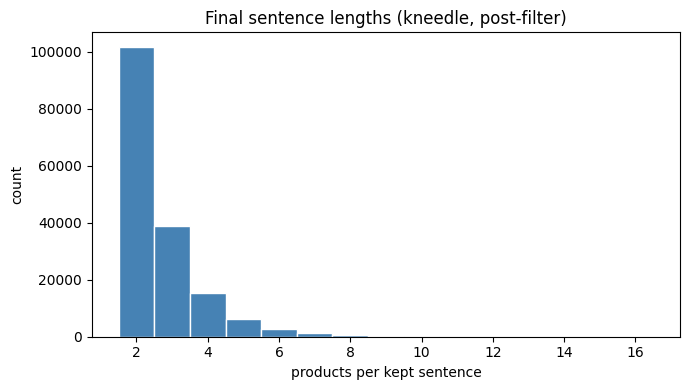

sentences kept   : 167,568
discarded (short): 232,532/400,100 (58.1%)
sentence length mean/median/max: 2.68 / 2 / 16


In [9]:
sent_lengths = [len(s["sentence"]) for s in kept_sentences]

fig, ax = plt.subplots(figsize=(7, 4))
if sent_lengths:
    ax.hist(sent_lengths, bins=range(min_sentence_length, max(sent_lengths) + 2),
            align="left", color="steelblue", edgecolor="white")
ax.set_title("Final sentence lengths (kneedle, post-filter)")
ax.set_xlabel("products per kept sentence"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,}/{n_total:,} "
      f"({100 * n_discarded / max(n_total, 1):.1f}%)")
if sent_lengths:
    print(f"sentence length mean/median/max: "
          f"{np.mean(sent_lengths):.2f} / {int(np.median(sent_lengths))} / {max(sent_lengths)}")

### Example walks

A handful of full walks for manual inspection: anchor, the raw path (every bridge the walk crossed), and the sentence the filter kept from it.

In [10]:
kept_filtered = [x for x in filtered if len(x["sentence"]) >= min_sentence_length]
display_rng = np.random.default_rng(0)
picks = (display_rng.choice(len(kept_filtered),
                            size=min(10, len(kept_filtered)), replace=False)
         if kept_filtered else [])

for i in picks:
    x = kept_filtered[int(i)]
    print("anchor   :", name(x["anchor_id"]))
    print("raw path :", " -> ".join(names(x["raw_path"])))
    print("sentence :", " -> ".join(names(x["sentence"])))
    print("hops     :", x["hops_taken"])
    print("-" * 90)

anchor   : Roasted Jalapeno Hummus
raw path : Roasted Jalapeno Hummus -> Organic Jalapeno Pepper -> Organic Pinto Beans -> Mild Salsa -> Yellow Soft Corn Tortillas 8 Count -> Guacamole -> Watermelon Chunks -> Crackers Cheddar Bunnies Snack Packs -> Organic Kale Pesto Hummus -> Jumbo White Onions -> Citrus Mandarins Organic -> Sharp Cheddar Deli Sliced Cheese -> 2% Milk Gallon -> Sea Salt Pita Chips -> Large Lemon -> Cabernet Sauvignon Wine
sentence : Roasted Jalapeno Hummus -> Guacamole -> Organic Kale Pesto Hummus
hops     : 15
------------------------------------------------------------------------------------------
anchor   : Trim Toniq Metabolism Enhancer
raw path : Trim Toniq Metabolism Enhancer -> Icelandic Style Fat Free Plain Yogurt -> Fruit & Nut Delight Bar -> High Protein Bar Chunky Peanut Butter -> Vanilla Almond Builder's Protein Bar -> Lime Sparkling Water -> Organic Garnet Sweet Potato (Yam) -> Organic Ezekiel 49 Bread Cinnamon Raisin -> Organic Small Bunch Celery -> Bag

## 8. Rank novelty — does the filter surface *new* substitutes?

For each stress-test anchor, look at every product its kept sentences surfaced and find where that product sits in Step 1's own full similarity ranking for the anchor (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new" — the walk + filter earns its keep only when it surfaces genuine substitutes ranked *far down* that list.

In [11]:
surfaced = {pid: Counter() for pid in STRESS_TEST_IDS}
for s in kept_sentences:
    a = s["anchor_id"]
    if a in surfaced:
        for p in s["sentence"]:
            if p != a:
                surfaced[a][p] += 1

# Compute each anchor's full similarity vector + rank lookup ONCE, then reuse it
# across all of that anchor's surfaced targets (instead of re-ranking per target).
print("Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?")
print("=" * 70)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"\n{nm} ({pid}) — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]        # cosine vs anchor (unit-norm)
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))        # rank[idx]: 0 = anchor, 1 = #1 neighbour
    print(f"\n{nm} ({pid})")
    surfaced_here = surfaced.get(pid, Counter())
    if not surfaced_here:
        print("  (no substitutes surfaced)")
    for p, c in surfaced_here.most_common():
        idx = pid_to_idx[p]
        rank = int(ranks[idx])
        flag = "  <- inside Step 1's own top-10, not new" if rank <= 10 else ""
        print(f"  {c}x  {name(p):<45} rank={rank:>6}  sim={sims[idx]:.3f}{flag}")

Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?

Whole Milk (4210)
  8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's own top-10, not new
  5x  Half & Half                                   rank=    57  sim=0.805
  3x  Organic Milk                                  rank=    22  sim=0.834
  3x  Fat Free Milk                                 rank=    29  sim=0.825
  2x  Yogurt, Lowfat, Strawberry                    rank=   137  sim=0.774
  2x  Chocolate Lowfat Milk                         rank=    31  sim=0.823
  2x  Organic Half & Half                           rank=   117  sim=0.778
  1x  Organic Lowfat 1% Milk                        rank=   125  sim=0.777
  1x  Large Eggs                                    rank=   124  sim=0.777
  1x  2% Chocolate Milk                             rank=    79  sim=0.791
  1x  Ultra-Filtered Whole Milk                     rank=    63  sim=0.802
  1x  Half And Half                    

## 9. Background popularity check

How common is each surfaced product overall? A "substitute" that appears in a huge fraction of baskets may just be popular rather than genuinely related. We read the per-product basket counts straight from `product_basket_freq.json` — no basket graph to rebuild.

In [12]:
print("Background popularity check: how common is each surfaced product overall?")
print("=" * 70)

for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor itself appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for p, c in surfaced.get(pid, Counter()).most_common(10):
        bg_freq = product_basket_count.get(p, 0)
        bg_pct = 100 * bg_freq / total_baskets if total_baskets else 0
        print(f"  {c}x found   {name(p):<40} appears in "
              f"{bg_freq:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity check: how common is each surfaced product overall?

Whole Milk (4210) — anchor itself appears in 11,103 / 1,000,000 baskets (1.1%)
  8x found   Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  5x found   Half & Half                              appears in  21,533 / 1,000,000 baskets (2.2%)
  3x found   Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
  3x found   Fat Free Milk                            appears in   9,189 / 1,000,000 baskets (0.9%)
  2x found   Yogurt, Lowfat, Strawberry               appears in   2,619 / 1,000,000 baskets (0.3%)
  2x found   Chocolate Lowfat Milk                    appears in   1,442 / 1,000,000 baskets (0.1%)
  2x found   Organic Half & Half                      appears in  23,541 / 1,000,000 baskets (2.4%)
  1x found   Organic Lowfat 1% Milk                   appears in   4,595 / 1,000,000 baskets (0.5%)
  1x found   Large Eggs                       

## 10. Adaptive vs fixed theta — the stress-test anchors

Each stress-test anchor's computed adaptive `theta` next to constant_theta's fixed 0.70. "stricter" means a higher bar than the baseline (fewer winners logged), "looser" a lower one. The last column shows the detected `knee_rank`, or "fallback" where no knee was found and the baseline was used instead.

In [13]:
print(f"Adaptive theta vs constant baseline ({CONSTANT_THETA_BASELINE}) — stress-test anchors")
print("=" * 84)
print(f"{'anchor':<30}{'adaptive':>9}{'fixed':>8}{'delta':>9}{'knee_rank':>12}  regime")
print("-" * 84)
for pid, nm in STRESS_TEST_IDS.items():
    t = anchor_thresholds.get(pid)
    if t is None:
        print(f"{nm:<30}{'(not walked / no threshold)':>38}")
        continue
    theta_a = t["theta"]
    delta = theta_a - CONSTANT_THETA_BASELINE
    if theta_a > CONSTANT_THETA_BASELINE:
        regime = "stricter"
    elif theta_a < CONSTANT_THETA_BASELINE:
        regime = "looser"
    else:
        regime = "equal"
    kr = "fallback" if t["fallback"] else str(t["knee_rank"])
    print(f"{nm:<30}{theta_a:>9.3f}{CONSTANT_THETA_BASELINE:>8.2f}{delta:>+9.3f}{kr:>12}  {regime}")

Adaptive theta vs constant baseline (0.7) — stress-test anchors
anchor                         adaptive   fixed    delta   knee_rank  regime
------------------------------------------------------------------------------------
Whole Milk                        0.773    0.70   +0.073         143  stricter
Unsweetened Almond Milk           0.723    0.70   +0.023         457  stricter
Organic Salted Butter             0.733    0.70   +0.033         153  stricter
Vegan Butter                      0.798    0.70   +0.098          11  stricter
Whole Milk Plain Yogurt           0.804    0.70   +0.104         169  stricter
Coconut Yogurt                    0.773    0.70   +0.073         467  stricter


## 11. Theta distribution across all anchors

The adaptive thresholds across every walked anchor, with the fixed 0.70 baseline marked (right of the line = stricter than the fixed method, left = looser). Then a second, separate histogram of `knee_rank` among the anchors where a knee was actually found — this shows directly whether detected knees cluster in a sane range (tens to low hundreds, consistent with what the rank-novelty tables have shown all along) or trail off past several thousand, which would signal Kneedle locking onto tail noise rather than a genuine boundary.

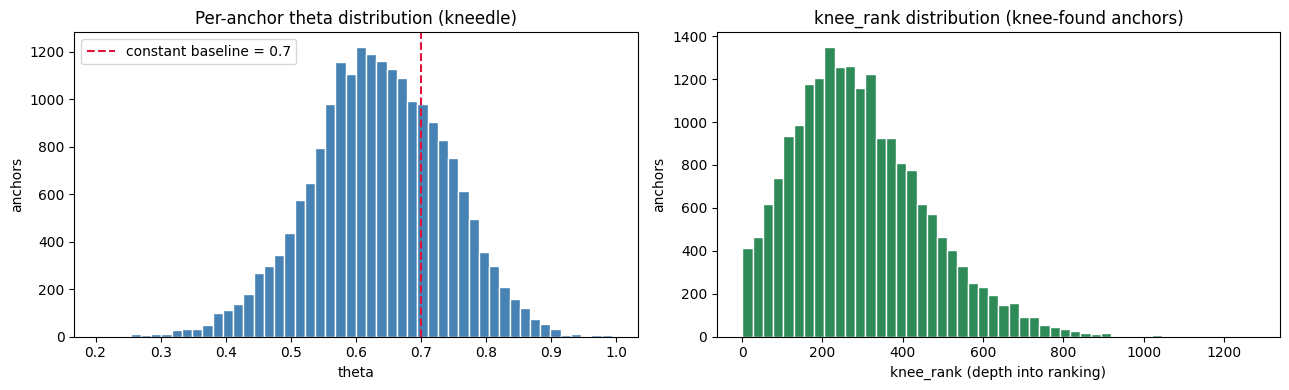

anchors with a threshold             : 20,005
stricter than 0.7 (theta > baseline)   : 5,572 (27.9%)
looser  than 0.7 (theta < baseline)   : 14,433 (72.1%)
knee_rank min/median/max             : 1 / 274 / 1276


In [14]:
thetas = np.array([t["theta"] for t in anchor_thresholds.values()])
n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())   # higher bar than the fixed baseline
n_looser = int((thetas < CONSTANT_THETA_BASELINE).sum())
n_equal = int((thetas == CONSTANT_THETA_BASELINE).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Left: theta distribution vs the fixed baseline.
if len(thetas):
    ax[0].hist(thetas, bins=50, color="steelblue", edgecolor="white")
ax[0].axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
              label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax[0].set_title("Per-anchor theta distribution (kneedle)")
ax[0].set_xlabel("theta"); ax[0].set_ylabel("anchors")
ax[0].legend()

# Right: knee_rank distribution, knee-found anchors only.
knee_ranks = np.array([t["knee_rank"] for t in anchor_thresholds.values()
                       if t["knee_rank"] is not None])
if len(knee_ranks):
    ax[1].hist(knee_ranks, bins=50, color="seagreen", edgecolor="white")
ax[1].set_title("knee_rank distribution (knee-found anchors)")
ax[1].set_xlabel("knee_rank (depth into ranking)"); ax[1].set_ylabel("anchors")

plt.tight_layout(); plt.show()

print(f"anchors with a threshold             : {len(thetas):,}")
print(f"stricter than {CONSTANT_THETA_BASELINE} (theta > baseline)   : {n_stricter:,} "
      f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")
print(f"looser  than {CONSTANT_THETA_BASELINE} (theta < baseline)   : {n_looser:,} "
      f"({100 * n_looser / max(len(thetas), 1):.1f}%)")
if n_equal:
    print(f"exactly {CONSTANT_THETA_BASELINE} (includes fallbacks)     : {n_equal:,}")
if len(knee_ranks):
    print(f"knee_rank min/median/max             : {knee_ranks.min()} / "
          f"{int(np.median(knee_ranks))} / {knee_ranks.max()}")

---
## 12. Transform filtered walks into human-readable format

In [15]:
readable_path = FILTER_DIR / "walk_sentences_readable.txt"
prev_anchor = None
with open(readable_path, "w") as f:
    for s in kept_sentences:
        if s["anchor_id"] != prev_anchor:
            if prev_anchor is not None:
                f.write("\n")
            prev_anchor = s["anchor_id"]
        f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

print(f"Saved {readable_path.name} ({len(kept_sentences):,} lines across "
      f"{len({s['anchor_id'] for s in kept_sentences}):,} anchors)")

Saved walk_sentences__kneedle_readable.txt (167,568 lines across 19,264 anchors)
